# Adaptive LameR

Run BM25 first. Compute semantic-similarity signals between the query and the top-k BM25 passages. Pass those signals to a small classifier trained on ``lamer_labels.csv`` to decide whether LameR is likely to improve nDCG/recall; if the classifier predicts a gain, invoke LameR, otherwise keep the BM25 results.


In [26]:
import sys
import os
import time
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Tuple

import joblib
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from scipy.stats import kurtosis, skew
from sentence_transformers import SentenceTransformer

# Make ``src`` importable when running from the ``notebooks/`` directory.
try:
    PROJECT_ROOT = Path(__file__).resolve().parent.parent
except NameError:
    PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.retriever import Retriever, create_retriever_callable
from src.agents.lamer import LameRAgent


## Configuration

In [27]:
load_dotenv(PROJECT_ROOT / ".env")

class Config:
    # Data paths (use the dev split for the classifier-driven test)
    QUERIES_PATH = PROJECT_ROOT / "notebooks" / "queries" / "topics.ms-marco-dev.tsv"
    QRELS_PATH = PROJECT_ROOT / "notebooks" / "qrels" / "qrels.ms-marco-dev.tsv"

    # Evaluation scope
    NUM_QUERIES = 30
    NDCG_K = 50
    RECALL_K = 100

    # Classifier and signal settings
    MODERATE_SIM_THRESHOLD = 0.5      # diagnostic threshold for count_above_moderate
    TOP_K_FOR_SIMILARITY = 20         # number of top BM25 passages used for the signals

    # Agent hyperparameters
    N_CANDIDATES = 5
    TOP_K_INITIAL = 20
    TOP_K_FINAL = 50

    # Output
    OUTPUT_DIR = PROJECT_ROOT / "outputs"
    OUTPUT_CSV = OUTPUT_DIR / "adaptive_lamer_results.csv"
    LAMER_CLASSIFIER_PATH = OUTPUT_DIR / "lamer_classifier.pkl"

cfg = Config()
cfg.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EMBED_MODEL = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
LLM_NAME = "google/gemma-4-E4B-it"


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7052.01it/s]


## Data loading helpers

In [28]:
def load_qrels(qrels_path: Path) -> Dict[str, Dict[str, int]]:
    """Load qrels as ``{query_id: {doc_id: relevance_grade}}``."""
    qrels = defaultdict(dict)
    if not qrels_path.exists():
        raise FileNotFoundError(f"Qrels file not found: {qrels_path}")

    with open(qrels_path, "r", encoding="utf-8") as f:
        next(f, None)  # Skip header.
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 4:
                continue
            query_id, doc_id, grade_str = parts[0].strip(), parts[2].strip(), parts[3].strip()
            try:
                grade = int(grade_str)
            except ValueError:
                continue
            qrels[query_id][doc_id] = grade
    return dict(qrels)


def load_queries(queries_path: Path, num_queries: int = None) -> List[Tuple[str, str]]:
    """Load queries as ``[(query_id, query_text), ...]``."""
    queries = []
    if not queries_path.exists():
        raise FileNotFoundError(f"Queries file not found: {queries_path}")

    with open(queries_path, "r", encoding="utf-8") as f:
        next(f, None)  # Skip header.
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) >= 2:
                query_id, query_text = parts[0].strip(), parts[1].strip()
            else:
                query_id, query_text = str(len(queries)), parts[0].strip()
            queries.append((query_id, query_text))
            if num_queries is not None and len(queries) >= num_queries:
                break
    return queries

## Metric helpers

In [29]:
def _dcg(relevances: np.ndarray, k: int) -> float:
    relevances = np.asarray(relevances, dtype=float)[:k]
    if relevances.size == 0:
        return 0.0
    positions = np.arange(2, relevances.size + 2)
    return float(np.sum(relevances / np.log2(positions)))


def normalize_doc_id(doc_id: str) -> str:
    """Strip segment suffix (e.g. 'doc#1' -> 'doc') to match qrels format."""
    return doc_id.split("#", 1)[0] if "#" in doc_id else doc_id


def deduplicate_doc_ids(doc_ids: List[str]) -> List[str]:
    """Normalize then deduplicate doc IDs."""
    deduped = []
    seen = set()
    for doc_id in doc_ids:
        normalized = normalize_doc_id(doc_id)
        if normalized not in seen:
            deduped.append(normalized)
            seen.add(normalized)
    return deduped


def compute_ndcg(ranked_doc_ids: List[str], qrels: Dict[str, int], k: int = 10) -> float:
    ranked_docs = deduplicate_doc_ids(ranked_doc_ids)[:k]
    gains = [qrels.get(doc_id, 0) for doc_id in ranked_docs]
    ideal = sorted((rel for rel in qrels.values() if rel > 0), reverse=True)[:k]
    dcg = _dcg(np.array(gains, dtype=float), k)
    idcg = _dcg(np.array(ideal, dtype=float), k)
    return dcg / idcg if idcg > 0 else 0.0


def compute_recall(ranked_doc_ids: List[str], qrels: Dict[str, int], k: int = 100) -> float:
    ranked_docs = deduplicate_doc_ids(ranked_doc_ids)[:k]
    relevant = {d for d, r in qrels.items() if r > 0}
    if not relevant:
        return 0.0
    return len(set(ranked_docs) & relevant) / len(relevant)

## Adaptive similarity signals and qrel-aware features

The classifier uses ground-truth relevance features (``bm25_ndcg`` and
``bm25_recall``) computed from the qrels. The semantic-similarity signals are
kept only for diagnostics.


In [30]:
def query_passage_similarity_signals(
    query_text: str,
    doc_ids: List[str],
    corpus: Dict[str, str],
    embed_model: SentenceTransformer,
    top_k: int = None,
) -> Dict[str, float]:
    """
    Embed the query and the first ``top_k`` retrieved passages and return
    several cosine-similarity based signals.

    These are kept for diagnostics; the classifier below uses qrel-aware
    retrieval-quality features instead.
    """
    if top_k is not None:
        doc_ids = doc_ids[:top_k]

    passages = [corpus.get(doc_id, "").strip() for doc_id in doc_ids]
    passages = [p for p in passages if p]

    if not passages:
        return {
            "mean_similarity": 0.0,
            "max_similarity": 0.0,
            "min_similarity": 0.0,
            "std_similarity": 0.0,
            "count_above_moderate": 0,
            "score_gap": 0.0,
        }

    query_embedding = embed_model.encode(query_text, convert_to_numpy=True)
    passage_embeddings = embed_model.encode(passages, convert_to_numpy=True)

    query_norm = query_embedding / (np.linalg.norm(query_embedding) + 1e-10)
    passage_norms = passage_embeddings / (np.linalg.norm(passage_embeddings, axis=1, keepdims=True) + 1e-10)
    similarities = passage_norms @ query_norm

    return {
        "mean_similarity": float(np.mean(similarities)),
        "max_similarity": float(np.max(similarities)),
        "min_similarity": float(np.min(similarities)),
        "std_similarity": float(np.std(similarities)),
        "count_above_moderate": int(np.sum(similarities >= cfg.MODERATE_SIM_THRESHOLD)),
        "score_gap": float(np.max(similarities) - np.min(similarities)),
    }


# These columns must match ``scripts/train_lamer_classifier.py``.
_CLASSIFIER_FEATURE_COLUMNS = [
    "bm25_ndcg",
    "bm25_recall",
    "bm25_ndcg_is_zero",
    "bm25_recall_is_zero",
]


def compute_qrel_features(
    bm25_doc_ids: List[str],
    qrels_for_query: Dict[str, int],
    k_ndcg: int = cfg.NDCG_K,
    k_recall: int = cfg.RECALL_K,
) -> Dict[str, float]:
    """Compute qrel-aware retrieval-quality features for the classifier."""
    bm25_ndcg = compute_ndcg(bm25_doc_ids, qrels_for_query, k=k_ndcg)
    bm25_recall = compute_recall(bm25_doc_ids, qrels_for_query, k=k_recall)
    return {
        "bm25_ndcg": bm25_ndcg,
        "bm25_recall": bm25_recall,
        "bm25_ndcg_is_zero": int(bm25_ndcg == 0),
        "bm25_recall_is_zero": int(bm25_recall == 0),
    }


def build_classifier_features(qrel_features: Dict[str, float]) -> np.ndarray:
    """Build the feature vector expected by the trained LameR classifier."""
    return np.array([[qrel_features[col] for col in _CLASSIFIER_FEATURE_COLUMNS]])


def should_call_lamer(qrel_features: Dict[str, float]) -> bool:
    """Ask the trained classifier whether LameR is likely to help this query."""
    features = build_classifier_features(qrel_features)
    proba = float(lamer_classifier.predict_proba(features)[0, 1])
    return proba >= lamer_threshold


## Initialize retriever, embedding model, and LameR agent

In [31]:
retriever_instance = Retriever(
    endpoint=os.getenv("RETRIEVAL_ENDPOINT"),
    username=os.getenv("MY_USERNAME"),
    password=os.getenv("MY_PASSWORD"),
    index_field="segment",
    top_k=cfg.TOP_K_FINAL,
)
retriever_func = create_retriever_callable(retriever_instance)

lamer_agent = LameRAgent(
    embed_model=EMBED_MODEL,
    n_candidates=cfg.N_CANDIDATES,
    top_k_initial=cfg.TOP_K_INITIAL,
    top_k_final=cfg.TOP_K_FINAL,
    model_name=LLM_NAME,
)

# Load the classifier trained on outputs/lamer_labels.csv.
lamer_artifact = joblib.load(cfg.LAMER_CLASSIFIER_PATH)
lamer_classifier = lamer_artifact["model"]
_classifier_feature_columns = lamer_artifact.get("features", _CLASSIFIER_FEATURE_COLUMNS)
lamer_threshold = lamer_artifact.get("threshold", 0.5)


[LameR] LLM client config: base_url=https://hub.nhr.fau.de/api/llmgw/v1, model=google/gemma-4-E4B-it


## Load data

In [32]:
queries = load_queries(cfg.QUERIES_PATH, num_queries=None)
qrels = load_qrels(cfg.QRELS_PATH)

# Keep only queries that have at least one relevant document in the qrels.
queries = [
    (query_id, query_text)
    for query_id, query_text in queries
    if any(grade > 0 for grade in qrels.get(query_id, {}).values())
]
queries = queries[:cfg.NUM_QUERIES]

print(f"Loaded {len(queries)} queries with at least one relevant document.")
print(f"Loaded qrels for {len(qrels)} queries.")


Loaded 30 queries with at least one relevant document.
Loaded qrels for 4552 queries.


## Run adaptive evaluation

For each query:
1. Retrieve top-k with BM25.
2. Compute semantic similarity signals between query and top-k passages.
3. Feed the signals to the trained classifier; if it predicts LameR will help, invoke LameR, otherwise keep BM25 results.
4. Evaluate both BM25 and adaptive result sets.


In [ ]:
records = []

for query_id, query_text in queries:
    print(f"[{len(records)+1}/{len(queries)}] Query {query_id}: {query_text[:60]}...")

    # Baseline BM25
    bm25_start = time.time()
    bm25_doc_ids, bm25_scores, bm25_corpus = retriever_func(query_text, cfg.TOP_K_FINAL)
    bm25_elapsed = time.time() - bm25_start

    bm25_scores_arr = np.asarray(bm25_scores, dtype=float)
    if len(bm25_scores_arr) >= 2:
        last_idx = min(9, len(bm25_scores_arr) - 1)
        bm25_score_gap = float(bm25_scores_arr[0] - bm25_scores_arr[last_idx])
    else:
        bm25_score_gap = 0.0

    qrels_for_query = qrels.get(query_id, {})
    qrel_features = compute_qrel_features(
        bm25_doc_ids,
        qrels_for_query,
        k_ndcg=cfg.NDCG_K,
        k_recall=cfg.RECALL_K,
    )

    # Adaptive decision
    decision_start = time.time()
    signals = query_passage_similarity_signals(
        query_text=query_text,
        doc_ids=bm25_doc_ids,
        corpus=bm25_corpus,
        embed_model=EMBED_MODEL,
        top_k=cfg.TOP_K_FOR_SIMILARITY,
    )

    features = build_classifier_features(qrel_features)
    lamer_proba = float(lamer_classifier.predict_proba(features)[0, 1])

    if should_call_lamer(qrel_features):
        # Classifier predicts a gain: invoke LameR
        effects = lamer_agent.compute_effects({
            "query_text": query_text,
            "retriever": retriever_func,
            "top_k": cfg.TOP_K_FINAL,
        })
        adaptive_doc_ids = effects["new_doc_ids"]
        augmented_query = effects["new_query_text"]
        used_lamer = True
        lamer_cost = effects["cost"]
    else:
        # Classifier predicts no gain: keep BM25 results
        adaptive_doc_ids = bm25_doc_ids
        augmented_query = query_text
        used_lamer = False
        lamer_cost = 0.0

    decision_elapsed = time.time() - decision_start

    # Metrics
    bm25_ndcg = compute_ndcg(bm25_doc_ids, qrels_for_query, k=cfg.NDCG_K)
    adaptive_ndcg = compute_ndcg(adaptive_doc_ids, qrels_for_query, k=cfg.NDCG_K)
    bm25_recall = compute_recall(bm25_doc_ids, qrels_for_query, k=cfg.RECALL_K)
    adaptive_recall = compute_recall(adaptive_doc_ids, qrels_for_query, k=cfg.RECALL_K)

    records.append({
        "query_id": query_id,
        "query_text": query_text,
        "mean_similarity": signals["mean_similarity"],
        "max_similarity": signals["max_similarity"],
        "min_similarity": signals["min_similarity"],
        "std_similarity": signals["std_similarity"],
        "count_above_moderate": signals["count_above_moderate"],
        "score_gap": signals["score_gap"],
        "bm25_ndcg": qrel_features["bm25_ndcg"],
        "bm25_recall": qrel_features["bm25_recall"],
        "used_lamer": used_lamer,
        "lamer_proba": lamer_proba,
        "augmented_query": augmented_query,
        "bm25_doc_ids": ";".join(bm25_doc_ids),
        "adaptive_doc_ids": ";".join(adaptive_doc_ids),
        "bm25_ndcg_eval": bm25_ndcg,
        "adaptive_ndcg": adaptive_ndcg,
        "ndcg_gain": adaptive_ndcg - bm25_ndcg,
        "bm25_recall_eval": bm25_recall,
        "adaptive_recall": adaptive_recall,
        "recall_gain": adaptive_recall - bm25_recall,
        "bm25_latency_ms": bm25_elapsed * 1000,
        "bm25_score_gap": bm25_score_gap,
        "adaptive_latency_ms": decision_elapsed * 1000,
        "augmented_extra_tokens": len(augmented_query.split()) - len(query_text.split()),
        "lamer_cost": lamer_cost,
    })

df = pd.DataFrame(records)
df.to_csv(cfg.OUTPUT_CSV, index=False)
print(f"Saved rankings + metrics to: {cfg.OUTPUT_CSV}")


[1/30] Query 2: Androgen receptor define...


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(

[2/30] Query 524332: treating tension headaches without medication...


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(

[3/30] Query 1048642: what is paranoid sc...


...

c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(

[18/30] Query 787255: what is project charter in project management...


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(

[LameR] Final candidates (5): ['A formal, typically short document that describes a project in its entirety.', "It outlines the project's objectives, how it will be carried out, and who the stakeholders are.", 'It is an official and authorized document detailing key objectives and responsibilities of a project.', 'The project charter is a crucial ingredient used throughout the project lifecycle for planning.', 'It specifies all important information, requests, plans, and outcomes of the project.']


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'opensearch.pads.fim.uni-passau.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


## Summarize

In [25]:
df = pd.DataFrame(records)

print(f"\nSaved per-query results to: {cfg.OUTPUT_CSV}")
print(f"Evaluated queries: {len(df)}")
print(f"Queries where LameR was invoked: {df['used_lamer'].sum()} ({df['used_lamer'].mean():.1%})")
print(f"Queries where at least one retrieval method retrieved a relevant document: {(df['bm25_ndcg'] + df['adaptive_ndcg'] > 0).sum()}")

print("\n=== Similarity signal averages ===")
print(f"Mean similarity:         {df['mean_similarity'].mean():.4f}")
print(f"Max similarity:          {df['max_similarity'].mean():.4f}")
print(f"Count above moderate:    {df['count_above_moderate'].mean():.2f}")
print(f"Score gap:               {df['score_gap'].mean():.4f}")

print("\n=== Overall Averages ===")
print(f"BM25       nDCG@{cfg.NDCG_K}:     {df['bm25_ndcg'].mean():.4f}")
print(f"Adaptive   nDCG@{cfg.NDCG_K}:     {df['adaptive_ndcg'].mean():.4f}")
print(f"Mean nDCG gain:                 {df['ndcg_gain'].mean():+.4f}")
print(f"Win rate (Adaptive > BM25):     {(df['ndcg_gain'] > 0).mean():.1%}")

print(f"\nBM25       Recall@{cfg.RECALL_K}:   {df['bm25_recall'].mean():.4f}")
print(f"Adaptive   Recall@{cfg.RECALL_K}:   {df['adaptive_recall'].mean():.4f}")
print(f"Mean Recall gain:               {df['recall_gain'].mean():+.4f}")

print(f"\nBM25     latency: {df['bm25_latency_ms'].mean():.1f} ms/query")
print(f"Adaptive latency: {df['adaptive_latency_ms'].mean():.1f} ms/query")
print(f"Total LameR cost: {df['lamer_cost'].sum():.0f} candidate calls")

print("\n=== Top 10 nDCG gains (Adaptive vs BM25) ===")
print(df.sort_values("ndcg_gain", ascending=False)[[
    "query_id", "query_text", "max_similarity", "count_above_moderate", "used_lamer", "ndcg_gain", "bm25_ndcg", "adaptive_ndcg"
]].head(10).to_string(index=False))

print("\n=== Top 10 nDCG losses (Adaptive vs BM25) ===")
print(df.sort_values("ndcg_gain", ascending=True)[[
    "query_id", "query_text", "max_similarity", "count_above_moderate", "used_lamer", "ndcg_gain", "bm25_ndcg", "adaptive_ndcg"
]].head(10).to_string(index=False))


Saved per-query results to: c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\outputs\adaptive_lamer_results.csv
Evaluated queries: 20
Queries where LameR was invoked: 4 (20.0%)
Queries where at least one retrieval method retrieved a relevant document: 5

=== Similarity signal averages ===
Mean similarity:         0.5489
Max similarity:          0.6902
Count above moderate:    12.50
Score gap:               0.3289

=== Overall Averages ===
BM25       nDCG@50:     0.0926
Adaptive   nDCG@50:     0.0831
Mean nDCG gain:                 -0.0095
Win rate (Adaptive > BM25):     5.0%

BM25       Recall@100:   0.2250
Adaptive   Recall@100:   0.2000
Mean Recall gain:               -0.0250

BM25     latency: 2446.9 ms/query
Adaptive latency: 2226.0 ms/query
Total LameR cost: 20 candidate calls

=== Top 10 nDCG gains (Adaptive vs BM25) ===
query_id                                    query_text  max_similarity  count_above_moderate  used_la

## Diagnostic plots

Visualize when LameR helps (red) vs. when it fires but does not help.

Plotting from live records (20 queries)


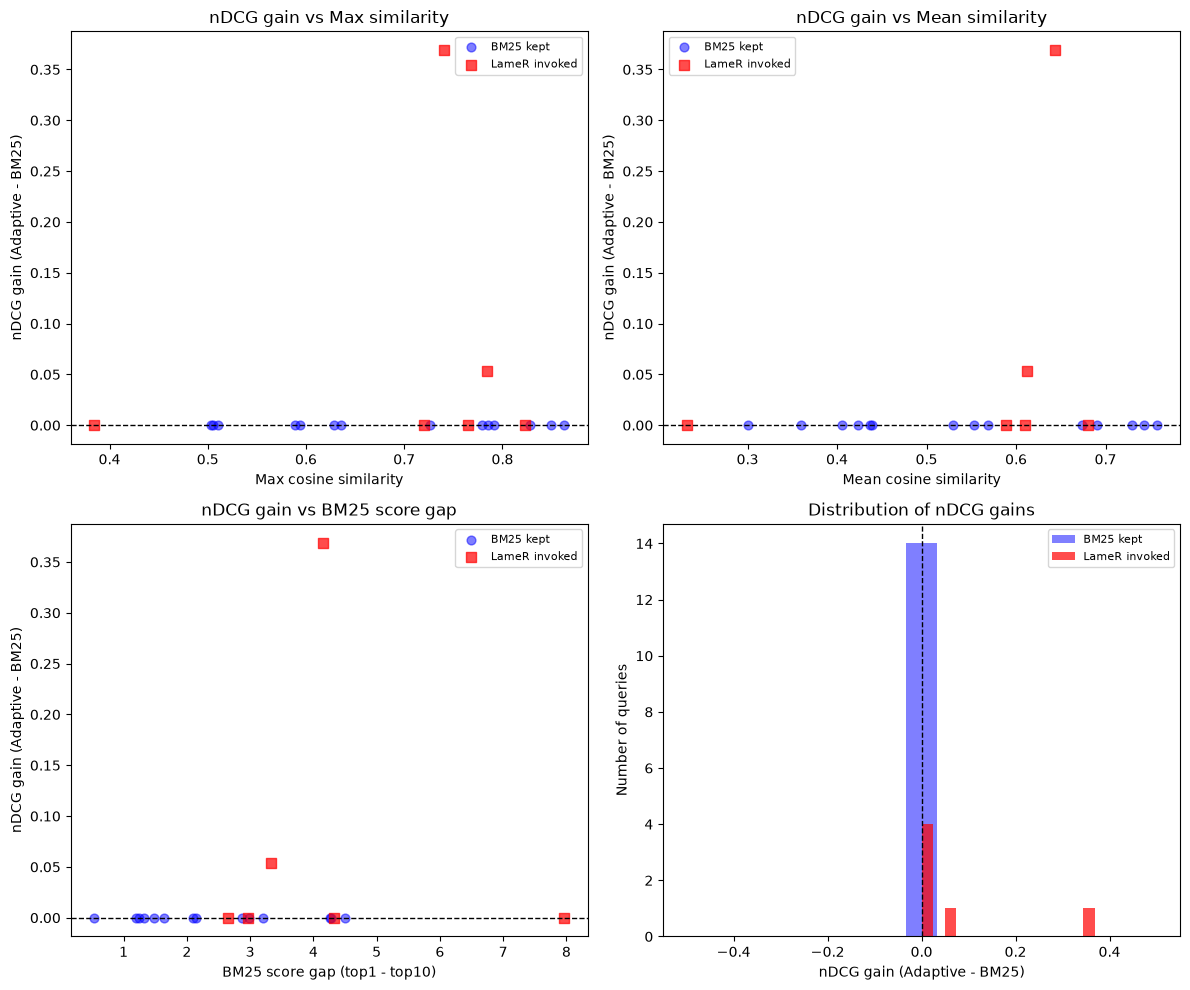

In [13]:
import matplotlib.pyplot as plt

# Prefer live records, but fall back to saved CSV so this cell can be re-run independently.
if "records" in globals() and records and "bm25_score_gap" in records[0]:
    df_plot = pd.DataFrame(records)
    source = "live records"
else:
    df_plot = pd.read_csv(cfg.OUTPUT_CSV)
    source = f"saved CSV ({cfg.OUTPUT_CSV})"

if "bm25_score_gap" not in df_plot.columns:
    raise KeyError(
        "'bm25_score_gap' is missing. Please re-run the evaluation cell above "
        "so the CSV includes the new column."
    )

print(f"Plotting from {source} ({len(df_plot)} queries)")

df_lamer = df_plot[df_plot["used_lamer"]]
df_nolamer = df_plot[~df_plot["used_lamer"]]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

def scatter_with_lines(ax, x_col, x_label, title):
    ax.scatter(
        df_nolamer[x_col], df_nolamer["ndcg_gain"],
        c="blue", alpha=0.5, s=40, label="BM25 kept"
    )
    ax.scatter(
        df_lamer[x_col], df_lamer["ndcg_gain"],
        c="red", alpha=0.7, s=60, marker="s", label="LameR invoked"
    )
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel(x_label)
    ax.set_ylabel("nDCG gain (Adaptive - BM25)")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)

scatter_with_lines(
    axes[0, 0], "max_similarity", "Max cosine similarity", "nDCG gain vs Max similarity"
)

scatter_with_lines(
    axes[0, 1], "mean_similarity", "Mean cosine similarity", "nDCG gain vs Mean similarity"
)

scatter_with_lines(
    axes[1, 0], "bm25_score_gap", "BM25 score gap (top1 - top10)", "nDCG gain vs BM25 score gap"
)

# Summary distribution
axes[1, 1].hist(df_nolamer["ndcg_gain"], bins=15, alpha=0.5, color="blue", label="BM25 kept")
axes[1, 1].hist(df_lamer["ndcg_gain"], bins=15, alpha=0.7, color="red", label="LameR invoked")
axes[1, 1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1, 1].set_xlabel("nDCG gain (Adaptive - BM25)")
axes[1, 1].set_ylabel("Number of queries")
axes[1, 1].set_title("Distribution of nDCG gains")
axes[1, 1].legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()
